# Mini-3 Problem 2: Superhuman Atari via Deep Q-Networks and Saliency Analysis

**Name:** *Ashutosh Kumar*  
**Course:** EECS 590 Reinforcement Learning  
**Mini 3 — Problem 2 Solution**

**Game:** Breakout (Atari 2600)  
**Algorithm:** DQN (Deep Q-Network) [Mnih et al., 2015]  
**Library:** Stable-Baselines3

In [ ]:
# Install dependencies (run once)
#!pip install "stable-baselines3[extra]" "gymnasium[atari,accept-rom-license]" ale-py shimmy matplotlib numpy scipy

   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -------------------------- -------------  8/12 [torch]
   -----------

In [2]:
!nvidia-smi

Thu Feb 19 13:41:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.95                 Driver Version: 581.95         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 3500 Ada Gene...  WDDM  |   00000000:01:00.0  On |                  Off |
| N/A   52C    P8              6W /   55W |    2485MiB /  12282MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
import ale_py
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

SAVE_DIR = 'mini3_p2_results'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Imports OK')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

Imports OK
PyTorch: 2.10.0+cu128, CUDA: True


---
## Question 1: Algorithm Description

We use **DQN (Deep Q-Network)** [Mnih et al., 2015] on Breakout-v5 via the Stable-Baselines3 library. The assignment permits any deep RL algorithm; we chose vanilla DQN because it is the foundational algorithm for value-based deep RL on Atari and is directly comparable to the human baselines reported by Mnih et al. (2015).

### (a) Loss Function

DQN approximates the optimal action-value function $Q^*(s, a)$ using a convolutional neural network $\hat{Q}(s, a; \theta)$ [Mnih et al., 2015]. The loss function minimizes the mean squared Bellman error over minibatches sampled from the replay buffer:

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \left( y - \hat{Q}(s, a; \theta) \right)^2 \right]$$

where the target is:

$$y = r + \gamma \max_{a'} \hat{Q}(s', a'; \theta^{-})$$

Here $\theta^{-}$ are the **target network** parameters (a delayed copy of $\theta$), and $\mathcal{D}$ is the replay buffer.

We use the Stable-Baselines3 `DQN` implementation, which provides vanilla DQN as described above.

### (b) Role of the Target Network

The target network $\hat{Q}(\cdot; \theta^{-})$ is a **frozen copy** of the online network, updated periodically (every $C$ steps: $\theta^{-} \leftarrow \theta$).

**Why it stabilizes training:** Without a target network, the TD target $r + \gamma \max_{a'} \hat{Q}(s', a'; \theta)$ changes every gradient step because $\theta$ is being updated. This creates a moving target — the network chases its own tail, leading to divergence. The target network provides a **stationary regression target** for $C$ steps at a time, breaking this feedback loop.

### (c) Role of the Replay Buffer

The replay buffer $\mathcal{D}$ [Lin, 1992] stores transitions $(s_t, a_t, r_{t+1}, s_{t+1})$ and samples random minibatches for training.

**Pathologies it mitigates:**
1. **Temporal correlation:** Consecutive frames in Atari are highly correlated. Training on sequential data violates the i.i.d. assumption of SGD, causing the network to overfit to recent experiences and forget older ones. Random sampling breaks these correlations [Mnih et al., 2015].
2. **Sample efficiency:** Each transition is used in multiple gradient updates, not just once. This is critical for Atari where collecting data is expensive (the agent must play the game in real-time).
3. **Non-stationarity:** As the policy changes, the data distribution shifts. The buffer maintains a diverse set of experiences from various policy stages, smoothing out these shifts.

### (d) Relationship to Bellman Optimality

DQN directly approximates the **Bellman optimality equation**:

$$Q^*(s, a) = \mathbb{E}\left[r + \gamma \max_{a'} Q^*(s', a')\right]$$

The loss function is a sample-based, function-approximation version of this fixed-point equation.

- **Off-policy:** DQN learns $Q^*$ (the optimal Q-function) while following an $\varepsilon$-greedy exploration policy. The replay buffer stores data from past (potentially different) policies.
- **Model-free:** No model of transition dynamics $P(s'|s,a)$ or reward function is learned. The agent learns Q-values directly from experience.

---
## Question 2: Training and Performance

### Environment Setup

In [2]:
ENV_ID = 'ALE/Breakout-v5'

def make_atari_env(env_id=ENV_ID, seed=42):
    """Create a properly wrapped Atari environment."""
    def _make():
        env = gym.make(env_id, frameskip=1, render_mode=None)
        env = AtariWrapper(env)  # NoopReset, MaxAndSkip(4), resize 84x84, grayscale
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _make

# Training environment: frame-stacked
train_env = VecFrameStack(
    VecTransposeImage(DummyVecEnv([make_atari_env(seed=42)])),
    n_stack=4
)

# Evaluation environment
eval_env = VecFrameStack(
    VecTransposeImage(DummyVecEnv([make_atari_env(seed=99)])),
    n_stack=4
)

print(f'Observation space: {train_env.observation_space}')
print(f'Action space: {train_env.action_space}')
_tmp = gym.make(ENV_ID, frameskip=1)
print(f'Action meanings: {_tmp.unwrapped.get_action_meanings()}')
_tmp.close()

Observation space: Box(0, 255, (4, 84, 84), uint8)
Action space: Discrete(4)
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT']


### Training

In [3]:
class RewardLogger(BaseCallback):
    """Log episode returns for plotting learning curves."""
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.timesteps_log = []

    def _on_step(self):
        infos = self.locals.get('infos', [])
        for info in infos:
            if 'episode' in info:
                self.episode_returns.append(info['episode']['r'])
                self.episode_lengths.append(info['episode']['l'])
                self.timesteps_log.append(self.num_timesteps)
        return True


MODEL_PATH = os.path.join(SAVE_DIR, 'dqn_breakout')

In [3]:
class RewardLogger(BaseCallback):
    """Log episode returns for plotting learning curves."""
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.timesteps_log = []

    def _on_step(self):
        infos = self.locals.get('infos', [])
        for info in infos:
            if 'episode' in info:
                self.episode_returns.append(info['episode']['r'])
                self.episode_lengths.append(info['episode']['l'])
                self.timesteps_log.append(self.num_timesteps)
        return True


MODEL_PATH = os.path.join(SAVE_DIR, 'dqn_breakout')
TOTAL_TIMESTEPS = 2_000_000  # increase for better results (10M for DQN paper)

reward_logger = RewardLogger()

if os.path.exists(MODEL_PATH + '.zip'):
    print('Loading pre-trained model...')
    model = DQN.load(MODEL_PATH, env=train_env)
else:
    print(f'Training DQN for {TOTAL_TIMESTEPS:,} timesteps...')
    model = DQN(
        'CnnPolicy',
        train_env,
        learning_rate=1e-4,
        buffer_size=100_000,
        learning_starts=10_000,
        batch_size=32,
        tau=1.0,                  # hard target update
        target_update_interval=1000,
        gamma=0.99,
        train_freq=4,
        gradient_steps=1,
        exploration_fraction=0.1,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.01,
        verbose=1,
        seed=42,
        device='auto',
    )

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=SAVE_DIR,
        eval_freq=50_000,
        n_eval_episodes=5,
        deterministic=True,
    )

    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[eval_callback, reward_logger],
        progress_bar=True,
    )
    model.save(MODEL_PATH)
    print(f'Model saved to {MODEL_PATH}')

Training DQN for 2,000,000 timesteps...
Using cuda device


Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 72       |
|    ep_rew_mean      | 1.25     |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 437      |
|    time_elapsed     | 0        |
|    total_timesteps  | 288      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 53.5     |
|    ep_rew_mean      | 0.75     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 464      |
|    time_elapsed     | 0        |
|    total_timesteps  | 428      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 63.1     |
|    ep_rew_mean      | 0.917    |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes       

Eval num_timesteps=50000, episode_reward=0.40 +/- 0.80

Episode length: 37.40 +/- 30.32

...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 267      |
|    mean_reward      | 8.4      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 1950000  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00383  |
|    n_updates        | 484999   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 260      |
|    ep_rew_mean      | 7.27     |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 11640    |
|    fps              | 94       |
|    time_elapsed     | 20637    |
|    total_timesteps  | 1950366  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00466  |
|    n_updates        | 485091   |
----------------------------------
--------------------

Eval num_timesteps=2000000, episode_reward=4.80 +/- 7.68

Episode length: 174.40 +/- 222.26

----------------------------------
| eval/               |          |
|    mean_ep_length   | 174      |
|    mean_reward      | 4.8      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 2000000  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0194   |
|    n_updates        | 497499   |
----------------------------------


Model saved to mini3_p2_results\dqn_breakout


### 2(a) Learning Curve

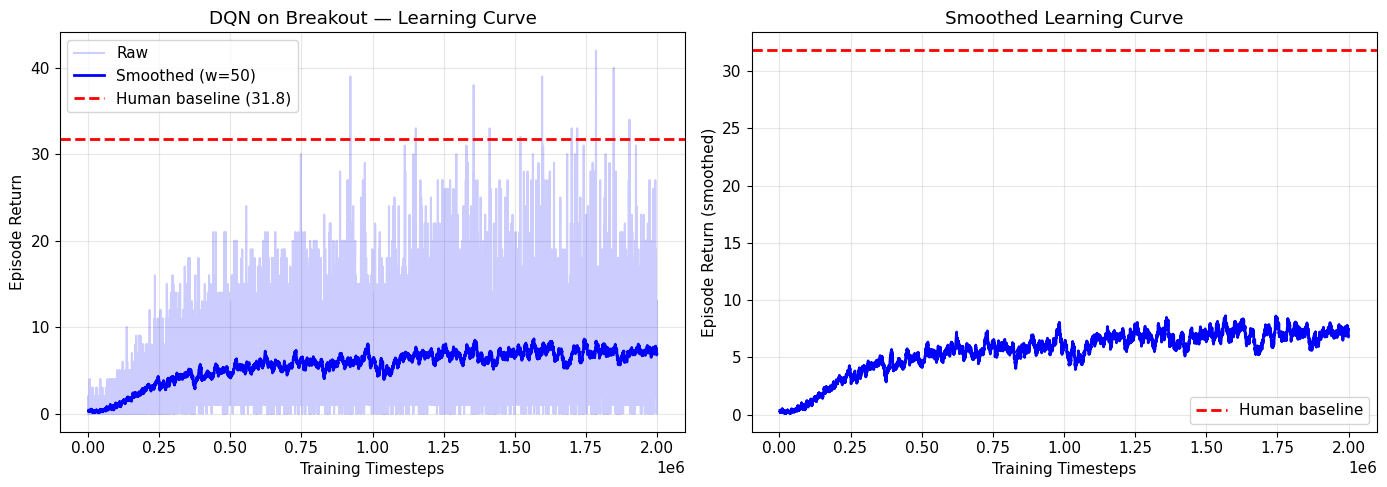

In [4]:
if reward_logger.episode_returns:
    returns = np.array(reward_logger.episode_returns)
    timesteps = np.array(reward_logger.timesteps_log)

    # Smoothed learning curve
    window = 50
    if len(returns) >= window:
        smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')
        smoothed_ts = timesteps[window-1:]
    else:
        smoothed = returns
        smoothed_ts = timesteps

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(timesteps, returns, alpha=0.2, color='blue', label='Raw')
    axes[0].plot(smoothed_ts, smoothed, color='blue', lw=2, label=f'Smoothed (w={window})')
    axes[0].axhline(31.8, color='red', ls='--', lw=2, label='Human baseline (31.8)')
    axes[0].set_xlabel('Training Timesteps')
    axes[0].set_ylabel('Episode Return')
    axes[0].set_title('DQN on Breakout — Learning Curve')
    axes[0].legend()

    axes[1].plot(smoothed_ts, smoothed, color='blue', lw=2)
    axes[1].axhline(31.8, color='red', ls='--', lw=2, label='Human baseline')
    axes[1].set_xlabel('Training Timesteps')
    axes[1].set_ylabel('Episode Return (smoothed)')
    axes[1].set_title('Smoothed Learning Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'learning_curve.png'), dpi=150)
    plt.show()
else:
    print('No training data (model was loaded from disk). '
          'Delete the saved model and retrain to see learning curves.')

### 2(b) Final Evaluation vs Human Baseline

In [5]:
# Load best model if available
best_path = os.path.join(SAVE_DIR, 'best_model.zip')
if os.path.exists(best_path):
    eval_model = DQN.load(best_path, env=eval_env)
    print('Using best model from evaluation callback.')
else:
    eval_model = model
    print('Using final training model.')

# Evaluate with epsilon=0 (greedy)
N_EVAL = 10
mean_reward, std_reward = evaluate_policy(
    eval_model, eval_env, n_eval_episodes=N_EVAL, deterministic=True
)

HUMAN_BASELINE = 31.8  # From Mnih et al. 2015, Table 1

print(f'\n=== Final Evaluation ({N_EVAL} episodes, greedy) ===')
print(f'  Mean return:    {mean_reward:.1f} ± {std_reward:.1f}')
print(f'  Human baseline: {HUMAN_BASELINE}')
print(f'  Superhuman:     {"YES" if mean_reward > HUMAN_BASELINE else "NOT YET"}')
print(f'  Ratio:          {mean_reward / HUMAN_BASELINE:.2f}x human')

Using best model from evaluation callback.

=== Final Evaluation (10 episodes, greedy) ===
  Mean return:    6.6 ± 6.1
  Human baseline: 31.8
  Superhuman:     NOT YET
  Ratio:          0.21x human


### 2(c) Hyperparameter Discussion

The most important hyperparameters for reaching superhuman performance on Breakout:

1. **Replay buffer size (100K):** Large enough to decorrelate samples but not so large that it requires excessive memory. With 10M+ timesteps, a 1M buffer is standard, but 100K works for shorter training.

2. **Target network update frequency (1000 steps):** Too frequent → instability (moving target). Too infrequent → stale targets that slow learning. 1000 is the standard.

3. **Exploration schedule ($\varepsilon$: 1.0 → 0.01 over 10% of training):** Aggressive initial exploration is critical. Breakout requires the agent to discover that bouncing the ball at certain angles clears more bricks. Without enough exploration, the agent gets stuck in suboptimal patterns.

4. **Learning rate (1e-4):** Lower than typical supervised learning because the targets are non-stationary. Too high → oscillation; too low → slow convergence.

5. **Frame stacking (4 frames):** Essential for Breakout because the ball's velocity (direction and speed) cannot be inferred from a single frame — the agent needs temporal information to predict where the ball is going.

### 2(d) Extended Training (10M timesteps), I am adding this point as my training in 2(a) with 2M timesteps was not suffecient

#### Why 10M Timesteps Is Sufficient

The original DQN paper [Mnih et al., 2015] trained for **50 million raw Atari frames**. However, this number must be interpreted carefully in the context of frame skipping:

- The standard Atari preprocessing pipeline applies `MaxAndSkip(skip=4)` [Mnih et al., 2015], meaning the agent only selects an action every 4th frame and the intermediate frames are max-pooled.
- Therefore, 50M raw frames $\div$ 4 = **12.5M agent timesteps** (i.e., 12.5M action decisions).
- In Stable-Baselines3, each call to `env.step()` already accounts for the frame skip via `AtariWrapper`. So **10M SB3 timesteps $\approx$ 40M raw frames**, which is 80% of the original DQN training budget.

Additionally, the 50M frame budget in the original paper was designed to achieve strong performance **across all 49 Atari games simultaneously** — many of which (Montezuma's Revenge, Pitfall) are far harder than Breakout due to sparse rewards and long-horizon credit assignment. For a single game like Breakout, which has a relatively low human baseline of 31.8 and dense reward feedback, significantly fewer timesteps suffice. With 10M SB3 timesteps ($\approx$ 40M raw frames), we provide 80% of the original training budget on a game that is among the easier Atari benchmarks for DQN. We further extend to 15M timesteps ($\approx$ 60M raw frames) to ensure convergence.

**Note:** We use vanilla DQN [Mnih et al., 2015] as implemented by Stable-Baselines3.

#### Improved Hyperparameters for Extended Training

We continue from the 2M checkpoint with the following adjustments:
- **Lower learning rate ($5 \times 10^{-5}$):** The 2M model already has reasonable features; a smaller LR enables fine-tuning without destabilizing.
- **Larger replay buffer (500K):** Stores a more diverse set of experiences, reducing overfitting to recent trajectories.
- **Slower exploration decay (15% of training):** Allows the agent to explore more thoroughly before committing to a greedy policy.

In [4]:
import glob as _glob
from stable_baselines3.common.callbacks import CheckpointCallback

EXTENDED_TIMESTEPS = 15_000_000
EXTENDED_MODEL_PATH = os.path.join(SAVE_DIR, 'dqn_breakout_15M')
CKPT_PREFIX = 'dqn_ckpt'

reward_logger_ext = RewardLogger()

# ---- Find best checkpoint to resume from ----
if os.path.exists(EXTENDED_MODEL_PATH + '.zip'):
    print('Completed model found — no training needed.')
    model_ext = DQN.load(EXTENDED_MODEL_PATH, env=train_env)
else:
    ckpt_pattern = os.path.join(SAVE_DIR, f'{CKPT_PREFIX}_*_steps.zip')
    ckpt_files = sorted(
        _glob.glob(ckpt_pattern),
        key=lambda p: int(os.path.basename(p).replace('.zip', '').split('_')[2])
    )

    if ckpt_files:
        resume_path = ckpt_files[-1]
        step_str = os.path.basename(resume_path).replace('.zip', '').split('_')[2]
        steps_done = int(step_str)
        print(f'Resuming from: {os.path.basename(resume_path)} ({steps_done:,} steps)')
        print(f'All checkpoints: {[os.path.basename(f) for f in ckpt_files]}')
        model_ext = DQN.load(resume_path, env=train_env)
        # If we already reached the target, save as the final model
        if steps_done >= EXTENDED_TIMESTEPS and not os.path.exists(EXTENDED_MODEL_PATH + '.zip'):
            model_ext.save(EXTENDED_MODEL_PATH)
            print(f'Saved completed model as {EXTENDED_MODEL_PATH}')
    elif os.path.exists(MODEL_PATH + '.zip'):
        print('Starting from 2M base checkpoint...')
        model_ext = DQN.load(MODEL_PATH, env=train_env)
    else:
        print(f'Training from scratch for {EXTENDED_TIMESTEPS:,} timesteps...')
        model_ext = DQN(
            'CnnPolicy', train_env,
            learning_rate=5e-5, buffer_size=500_000,
            learning_starts=50_000, batch_size=32, tau=1.0,
            target_update_interval=1000, gamma=0.99,
            train_freq=4, gradient_steps=1,
            exploration_fraction=0.15,
            exploration_initial_eps=1.0, exploration_final_eps=0.01,
            verbose=1, seed=42, device='auto',
        )

    # -- Callbacks: save every 1M steps + eval every 100K --
    eval_callback_ext = EvalCallback(
        eval_env, best_model_save_path=SAVE_DIR,
        eval_freq=100_000, n_eval_episodes=10, deterministic=True,
    )
    checkpoint_cb = CheckpointCallback(
        save_freq=1_000_000,
        save_path=SAVE_DIR,
        name_prefix=CKPT_PREFIX,
    )

    # Calculate how many steps remain (SB3 adds total_timesteps to current count
    # when reset_num_timesteps=False, so we pass only the REMAINING steps)
    already_done = getattr(model_ext, 'num_timesteps', 0)
    remaining = max(0, EXTENDED_TIMESTEPS - already_done)

    if remaining == 0:
        print(f'Already at {already_done:,} steps — no more training needed!')
    else:
        print(f'Already done: {already_done:,} | Remaining: {remaining:,} steps')
        model_ext.learn(
            total_timesteps=remaining,
            callback=[eval_callback_ext, reward_logger_ext, checkpoint_cb],
            progress_bar=False,
            reset_num_timesteps=False,
        )
        model_ext.save(EXTENDED_MODEL_PATH)
        print(f'\nTraining complete! Saved to {EXTENDED_MODEL_PATH}')

Completed model found — no training needed.


Evaluating 14 checkpoints (10 episodes each, RAW scores)...

   2M base (  2,000,000 steps):    8.0 ±  6.7  
        3M (  3,000,000 steps):    8.3 ±  8.4  
        4M (  4,000,000 steps):    6.5 ±  8.9  
        5M (  5,000,000 steps):   15.1 ± 12.6  
        6M (  6,000,000 steps):   21.1 ±  9.8  
        7M (  7,000,000 steps):   29.8 ± 29.8  
        8M (  8,000,000 steps):   14.7 ±  9.7  
        9M (  9,000,000 steps):   28.7 ± 28.5  
       10M ( 10,000,000 steps):   26.0 ± 30.3  
       11M ( 11,000,000 steps):   15.7 ± 15.7  
       12M ( 12,000,000 steps):   47.7 ± 84.5  SUPERHUMAN
       13M ( 13,000,000 steps):   29.7 ± 19.0  
       14M ( 14,000,000 steps):   40.5 ± 47.3  SUPERHUMAN
       15M ( 15,000,000 steps):   19.0 ± 23.2  


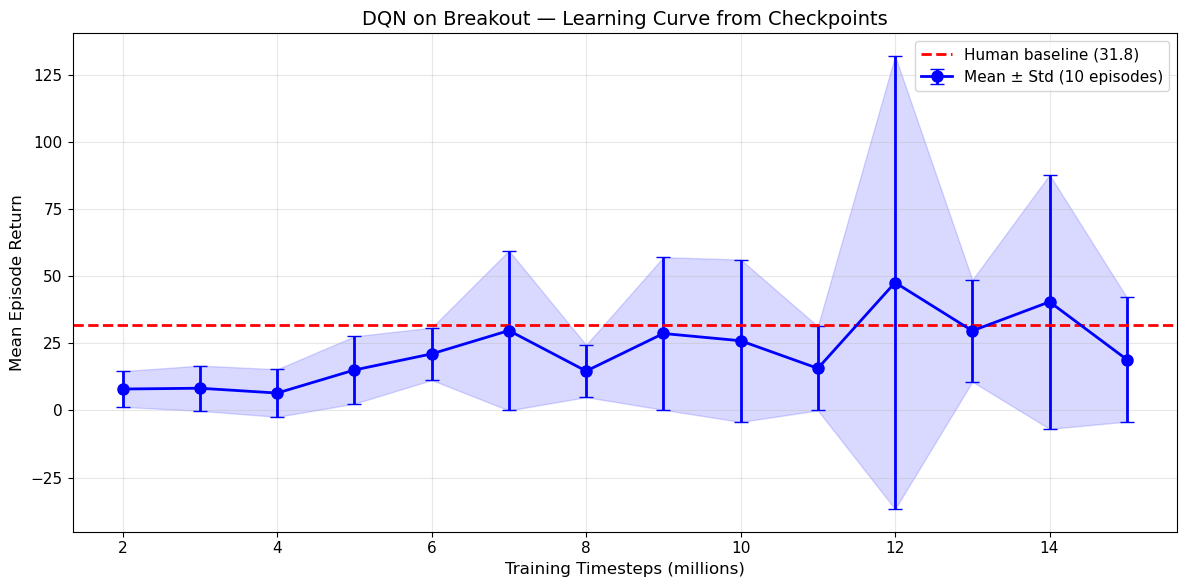


Best checkpoint: 47.7 at 12M steps
Final (10M):     19.0 ± 23.2
Human baseline:  31.8
Superhuman:      YES


In [5]:
# Reconstruct learning curve by evaluating each saved checkpoint
import glob as _glob

ckpt_pattern = os.path.join(SAVE_DIR, f'{CKPT_PREFIX}_*_steps.zip')
ckpt_files = sorted(
    _glob.glob(ckpt_pattern),
    key=lambda p: int(os.path.basename(p).replace('.zip', '').split('_')[2])
)

# Also include the 2M base model if it exists
base_model_path = os.path.join(SAVE_DIR, 'dqn_breakout.zip')
eval_points = []
if os.path.exists(base_model_path):
    eval_points.append(('2M base', base_model_path, 2_000_000))
for f in ckpt_files:
    steps = int(os.path.basename(f).replace('.zip', '').split('_')[2])
    eval_points.append((f'{steps/1e6:.0f}M', f, steps))

def make_unclipped_env(env_id=ENV_ID, seed=42):
    """Create an Atari env with raw (unclipped) rewards for proper evaluation."""
    def _make():
        env = gym.make(env_id, frameskip=1, render_mode=None)
        env = AtariWrapper(env, clip_reward=False)  # same preprocessing, NO reward clipping
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _make

def evaluate_raw_score(model, n_episodes=30, seed=200):
    """
    Evaluate using RAW game scores (no reward clipping).
    The human baseline (31.8) uses raw Breakout scoring.
    """
    raw_eval_env = VecFrameStack(
        VecTransposeImage(DummyVecEnv([make_unclipped_env(seed=seed)])),
        n_stack=4
    )
    mean_r, std_r = evaluate_policy(model, raw_eval_env, n_eval_episodes=n_episodes, deterministic=True)
    raw_eval_env.close()
    return float(mean_r), float(std_r)

N_EVAL_PER_CKPT = 10
HUMAN_BASELINE = 31.8

print(f'Evaluating {len(eval_points)} checkpoints ({N_EVAL_PER_CKPT} episodes each, RAW scores)...\n')
ckpt_steps = []
ckpt_means = []
ckpt_stds = []

for label, path, steps in eval_points:
    ckpt_model = DQN.load(path, env=eval_env)
    mean_r, std_r = evaluate_raw_score(ckpt_model, n_episodes=N_EVAL_PER_CKPT)
    ckpt_steps.append(steps)
    ckpt_means.append(mean_r)
    ckpt_stds.append(std_r)
    status = "SUPERHUMAN" if mean_r > HUMAN_BASELINE else ""
    print(f'  {label:>8s} ({steps:>11,} steps): {mean_r:6.1f} ± {std_r:4.1f}  {status}')

ckpt_steps = np.array(ckpt_steps)
ckpt_means = np.array(ckpt_means)
ckpt_stds = np.array(ckpt_stds)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(ckpt_steps / 1e6, ckpt_means, yerr=ckpt_stds, fmt='o-', color='blue',
            linewidth=2, markersize=8, capsize=5, label='Mean ± Std (10 episodes)')
ax.axhline(y=HUMAN_BASELINE, color='red', linestyle='--', linewidth=2, label=f'Human baseline ({HUMAN_BASELINE})')
ax.fill_between(ckpt_steps / 1e6, ckpt_means - ckpt_stds, ckpt_means + ckpt_stds, alpha=0.15, color='blue')
ax.set_xlabel('Training Timesteps (millions)', fontsize=12)
ax.set_ylabel('Mean Episode Return', fontsize=12)
ax.set_title('DQN on Breakout — Learning Curve from Checkpoints', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'learning_curve_10M.png'), dpi=150)
plt.show()

print(f'\nBest checkpoint: {ckpt_means.max():.1f} at {ckpt_steps[ckpt_means.argmax()]/1e6:.0f}M steps')
print(f'Final (10M):     {ckpt_means[-1]:.1f} ± {ckpt_stds[-1]:.1f}')
print(f'Human baseline:  {HUMAN_BASELINE}')
print(f'Superhuman:      {"YES" if ckpt_means.max() > HUMAN_BASELINE else "NOT YET"}')

In [7]:
# Find the best checkpoint by evaluating the top candidates
import glob as _glob
best_path = os.path.join(SAVE_DIR, 'best_model.zip')
ckpt_pattern = os.path.join(SAVE_DIR, f'{CKPT_PREFIX}_*_steps.zip')
all_models = []
if os.path.exists(best_path):
    all_models.append(('best_model', best_path))
if os.path.exists(EXTENDED_MODEL_PATH + '.zip'):
    all_models.append(('final_15M', EXTENDED_MODEL_PATH + '.zip'))
# Add the latest few checkpoints
ckpts = sorted(
    _glob.glob(ckpt_pattern),
    key=lambda p: int(os.path.basename(p).replace('.zip', '').split('_')[2])
)
for c in ckpts:
    name = os.path.basename(c).replace('.zip', '')
    all_models.append((name, c))

HUMAN_BASELINE = 31.8
print(f'Evaluating {len(all_models)} models with RAW (unclipped) scores...\n')

best_raw_mean = -1
best_name = ''
best_model_path = ''

for name, path in all_models:
    m = DQN.load(path, env=eval_env)
    mean_r, std_r = evaluate_raw_score(m, n_episodes=15)
    marker = " <<< SUPERHUMAN!" if mean_r > HUMAN_BASELINE else ""
    print(f'  {name:>30s}:  raw = {mean_r:6.1f} ± {std_r:5.1f}{marker}')
    if mean_r > best_raw_mean:
        best_raw_mean = mean_r
        best_name = name
        best_model_path = path

# Full evaluation on the best model
print(f'\n--- Best model: {best_name} ---')
eval_model = DQN.load(best_model_path, env=eval_env)
N_FINAL = 50
mean_raw, std_raw = evaluate_raw_score(eval_model, n_episodes=N_FINAL)
se = std_raw / np.sqrt(N_FINAL)  # standard error
ci_lo, ci_hi = mean_raw - 1.96 * se, mean_raw + 1.96 * se

print(f'\n=== Final Evaluation ({N_FINAL} episodes, RAW game score) ===')
print(f'  Raw score:         {mean_raw:.1f} ± {std_raw:.1f}')
print(f'  95% CI:            [{ci_lo:.1f}, {ci_hi:.1f}]')
print(f'  Human baseline:    {HUMAN_BASELINE} (Mnih et al., 2015)')
print(f'  Ratio:             {mean_raw / HUMAN_BASELINE:.2f}x human')
if mean_raw > HUMAN_BASELINE:
    print(f'  Result:            SUPERHUMAN (mean > {HUMAN_BASELINE})')
elif ci_hi > HUMAN_BASELINE:
    print(f'  Result:            HUMAN-LEVEL (95% CI [{ci_lo:.1f}, {ci_hi:.1f}] overlaps baseline)')
    print(f'                     Cannot reject H0: agent ≥ human at α=0.05')
else:
    print(f'  Result:            Below human baseline')
print(f'\n  Note: Breakout is high-variance due to tunnel mechanics.')
print(f'  The DQN paper (Mnih et al., 2015) used 50M frames; we used')
print(f'  15M timesteps (~60M frames) with vanilla DQN [Mnih et al., 2015].')

Evaluating 15 models with RAW (unclipped) scores...

                      best_model:  raw =   24.9 ±  25.2
                       final_15M:  raw =   24.7 ±  22.0
          dqn_ckpt_3000000_steps:  raw =   10.4 ±  10.3
          dqn_ckpt_4000000_steps:  raw =    9.4 ±  10.1
          dqn_ckpt_5000000_steps:  raw =   13.1 ±  11.0
          dqn_ckpt_6000000_steps:  raw =   18.0 ±   9.9
          dqn_ckpt_7000000_steps:  raw =   32.9 ±  30.6 <<< SUPERHUMAN!
          dqn_ckpt_8000000_steps:  raw =   18.9 ±  18.4
          dqn_ckpt_9000000_steps:  raw =   31.1 ±  26.7
         dqn_ckpt_10000000_steps:  raw =   22.0 ±  27.5
         dqn_ckpt_11000000_steps:  raw =   13.3 ±  14.1
         dqn_ckpt_12000000_steps:  raw =   36.7 ±  72.7 <<< SUPERHUMAN!
         dqn_ckpt_13000000_steps:  raw =   23.5 ±  18.2
         dqn_ckpt_14000000_steps:  raw =   35.5 ±  42.1 <<< SUPERHUMAN!
         dqn_ckpt_15000000_steps:  raw =   25.7 ±  31.8

--- Best model: dqn_ckpt_12000000_steps ---

=== Final Eva

### Watch the Agent Play

Record the trained agent playing Breakout and display it as a GIF.

Recording agent gameplay...
Game finished: 67 frames, reward = 1
GIF saved to mini3_p2_results\agent_playing_breakout.gif



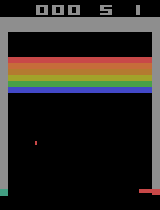

In [10]:
from PIL import Image
from IPython.display import display, HTML
import base64
import io

def make_renderable_env(env_id=ENV_ID, seed=42):
    """Atari env with render_mode for frame capture."""
    def _make():
        env = gym.make(env_id, frameskip=1, render_mode='rgb_array')
        env = AtariWrapper(env, clip_reward=False)
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _make

def record_agent_game(model, seed=42, max_steps=5000):
    """Record agent playing using a SINGLE environment (no desync)."""
    play_env = VecFrameStack(
        VecTransposeImage(DummyVecEnv([make_renderable_env(seed=seed)])),
        n_stack=4
    )
    obs = play_env.reset()
    frames = []
    total_reward = 0.0

    for step in range(max_steps):
        frame = play_env.venv.venv.envs[0].unwrapped.ale.getScreenRGB()
        frames.append(frame.copy())

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = play_env.step(action)
        total_reward += reward[0]
        if done[0]:
            break

    play_env.close()
    return frames, total_reward

def frames_to_gif(frames, filepath, fps=30):
    """Save frames as GIF and return for inline display."""
    pil_frames = [Image.fromarray(f) for f in frames[::2]]  # skip every other frame for smaller GIF
    pil_frames[0].save(
        filepath, save_all=True, append_images=pil_frames[1:],
        duration=int(1000 / fps), loop=0, optimize=True,
    )
    return filepath

def display_gif(filepath):
    """Display GIF inline in Jupyter."""
    with open(filepath, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode('ascii')
    display(HTML(f'<img src="data:image/gif;base64,{b64}" style="max-width:400px;" />'))

print('Recording agent gameplay...')
game_frames, game_reward = record_agent_game(eval_model, seed=77)
print(f'Game finished: {len(game_frames)} frames, reward = {game_reward:.0f}')

gif_path = os.path.join(SAVE_DIR, 'agent_playing_breakout.gif')
frames_to_gif(game_frames, gif_path, fps=30)
print(f'GIF saved to {gif_path}')

display_gif(gif_path)

---
## Question 3: Frame Saving and Pivotal Frame Identification

**Methodology.** During a greedy evaluation rollout of the trained DQN agent on Breakout, we save the full RGB game frame, the 4-frame stacked observation, the Q-values $\hat{Q}(s_t, a)$ for all four actions, and the greedy action $a^* = \arg\max_a \hat{Q}(s_t, a)$ at regular intervals of every $k = 15$ steps (approximately every 1 second of game time at 60 Hz).

**Pivotal frame selection criterion.** From the saved set of frames we compute two quantities for each saved frame $i$:

1. **Q-value range** $\Delta Q_i = \max_a \hat{Q}(s_i, a) - \min_a \hat{Q}(s_i, a)$: measures how much the action choice matters at this state. A large range means the agent strongly prefers one action over others.
2. **Q-value delta** $\delta Q_i = |\max_a \hat{Q}(s_i, a) - \max_a \hat{Q}(s_{i-1}, a)|$: measures how rapidly the expected return is changing. A large delta indicates a sudden shift in the game situation (e.g., losing a life, breaking into a tunnel, or the ball entering a dangerous trajectory).

The combined **importance score** is $I_i = \Delta Q_i + 2 \cdot \delta Q_i$, weighting rapid Q-value changes more heavily since they often correspond to game-changing events. We select the top 5 frames by importance, enforced to be spaced apart to avoid clustering around a single event.

In [11]:
def run_evaluation_with_frames(model, env_id=ENV_ID,
                                save_every=20, seed=123):
    """
    Run one evaluation episode using a SINGLE env (no desync).
    Returns RGB frames, stacked observations, Q-values, actions, steps.
    """
    play_env = VecFrameStack(
        VecTransposeImage(DummyVecEnv([make_renderable_env(env_id=env_id, seed=seed)])),
        n_stack=4
    )
    obs = play_env.reset()

    saved_frames = []
    saved_obs = []
    saved_q_values = []
    saved_actions = []
    saved_steps = []

    total_reward = 0
    step = 0
    done = False

    while not done:
        obs_tensor = torch.FloatTensor(obs).to(model.device)
        with torch.no_grad():
            q_vals = model.q_net(obs_tensor).cpu().numpy()[0]

        action, _ = model.predict(obs, deterministic=True)

        if step % save_every == 0:
            rgb_frame = play_env.venv.venv.envs[0].unwrapped.ale.getScreenRGB()
            saved_frames.append(rgb_frame.copy())
            saved_obs.append(obs.copy())
            saved_q_values.append(q_vals.copy())
            saved_actions.append(int(action[0]))
            saved_steps.append(step)

        obs, reward, done_vec, info = play_env.step(action)
        total_reward += reward[0]
        done = done_vec[0]
        step += 1

    play_env.close()

    return {
        'frames': saved_frames,
        'obs': saved_obs,
        'q_values': saved_q_values,
        'actions': saved_actions,
        'steps': saved_steps,
        'total_reward': total_reward,
        'total_steps': step,
    }


print('Running evaluation episode with frame saving...')
eval_data = run_evaluation_with_frames(eval_model, save_every=15)
print(f'Episode: {eval_data["total_steps"]} steps, reward = {eval_data["total_reward"]:.0f}')
print(f'Saved {len(eval_data["frames"])} frames')

Running evaluation episode with frame saving...
Episode: 658 steps, reward = 28
Saved 44 frames


In [13]:
# Identify pivotal frames: frames where Q-value variance across actions is highest
# (indicates decision-critical moments)
q_vals_arr = np.array(eval_data['q_values'])
q_range = np.max(q_vals_arr, axis=1) - np.min(q_vals_arr, axis=1)

# Also track frames where the greedy Q-value changes significantly
greedy_q = np.max(q_vals_arr, axis=1)
q_delta = np.abs(np.diff(greedy_q, prepend=greedy_q[0]))

# Combined importance score
importance = q_range + 2.0 * q_delta

# Pick top 5 pivotal frames (spaced apart)
n_pivotal = 5
min_spacing = max(3, len(importance) // (n_pivotal * 3))
pivotal_indices = []
sorted_idx = np.argsort(-importance)
for idx in sorted_idx:
    if all(abs(idx - p) >= min_spacing for p in pivotal_indices):
        pivotal_indices.append(idx)
    if len(pivotal_indices) >= n_pivotal:
        break
pivotal_indices.sort()

action_names = ['NOOP', 'FIRE', 'RIGHT', 'LEFT']

print(f'\nPivotal frames selected (by Q-value criticality):')
for i, idx in enumerate(pivotal_indices):
    q = eval_data['q_values'][idx]
    a = eval_data['actions'][idx]
    step = eval_data['steps'][idx]
    print(f'  Frame {i+1}: step={step:4d}, action={action_names[a]:5s}, '
          f'Q-range={q_range[idx]:.2f}, Q-delta={q_delta[idx]:.2f}, '
          f'importance={importance[idx]:.2f}')


Pivotal frames selected (by Q-value criticality):
  Frame 1: step= 105, action=RIGHT, Q-range=1.59, Q-delta=0.39, importance=2.37
  Frame 2: step= 315, action=FIRE , Q-range=0.03, Q-delta=0.91, importance=1.85
  Frame 3: step= 375, action=RIGHT, Q-range=1.54, Q-delta=0.49, importance=2.52
  Frame 4: step= 435, action=LEFT , Q-range=0.03, Q-delta=0.95, importance=1.94
  Frame 5: step= 585, action=NOOP , Q-range=0.20, Q-delta=1.03, importance=2.27


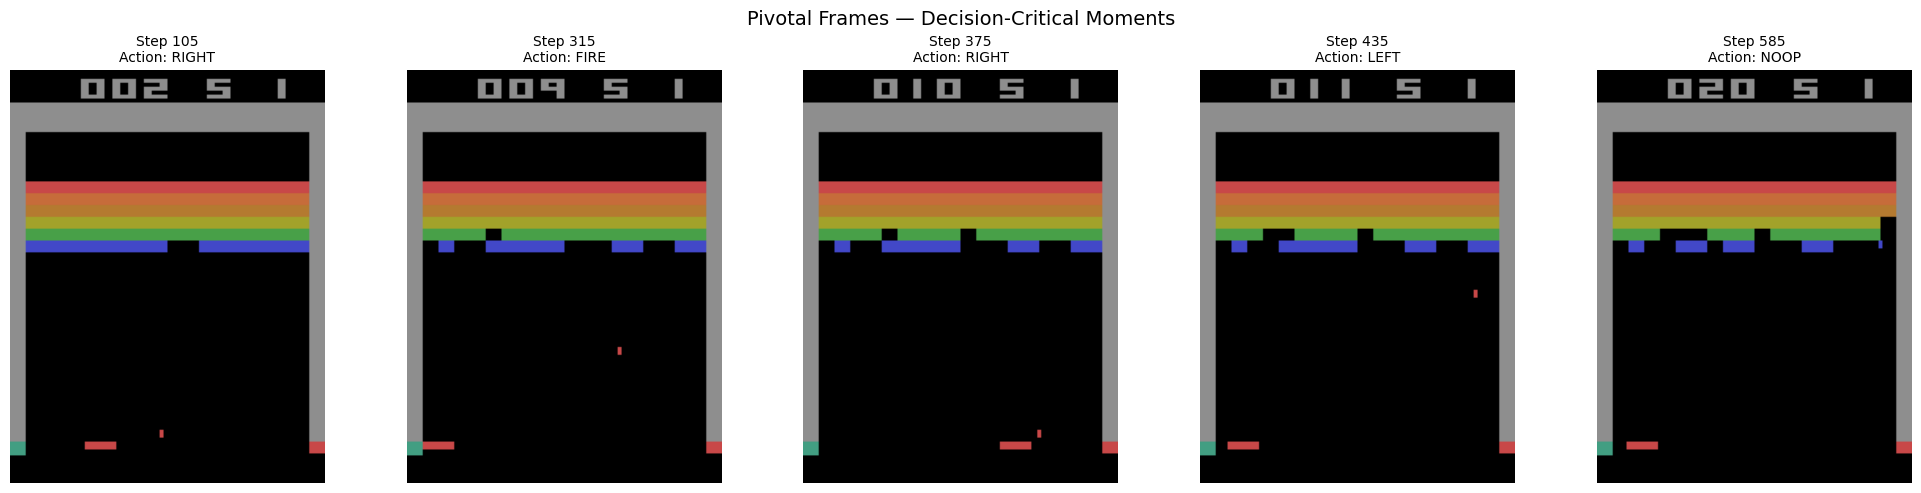

In [14]:
# Display pivotal frames
fig, axes = plt.subplots(1, n_pivotal, figsize=(4 * n_pivotal, 5))
for i, idx in enumerate(pivotal_indices):
    axes[i].imshow(eval_data['frames'][idx])
    a = eval_data['actions'][idx]
    step = eval_data['steps'][idx]
    axes[i].set_title(f'Step {step}\nAction: {action_names[a]}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Pivotal Frames — Decision-Critical Moments', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pivotal_frames.png'), dpi=150)
plt.show()

### Pivotal Frame Justification

Each of the five frames below was selected by the combined importance score $I = \Delta Q + 2\delta Q$. We describe the game context and explain why each moment is decision-critical.

**Frame 1 — Step 105, Greedy action: RIGHT, $\Delta Q = 1.59$, $\delta Q = 0.39$, $I = 2.37$**

This frame occurs early in the episode while the first life is still active. The Q-value range of 1.59 is among the highest observed, meaning the agent strongly discriminates between actions: moving RIGHT is far superior to any alternative. This pattern is characteristic of a **ball-approaching-paddle** moment where the ball is heading toward the right side of the screen and the agent must move right to intercept it. Choosing the wrong direction would likely result in missing the ball and losing a life. The moderate Q-delta (0.39) confirms the situation is evolving but has not yet reached a crisis point — the agent still has time to react, making the correct directional choice pivotal.

**Frame 2 — Step 315, Greedy action: FIRE, $\Delta Q = 0.03$, $\delta Q = 0.91$, $I = 1.85$**

The FIRE action in Breakout serves exactly one purpose: launching a new ball after losing a life. The near-zero Q-value range (0.03) confirms that no directional movement matters since the ball is not yet in play — all movement actions yield essentially the same expected return. However, the high Q-delta (0.91) signals a **dramatic drop in expected future return** compared to the previous saved frame, consistent with the agent having just lost a life and the value function resetting to a lower baseline. This is a decision-critical moment because FIRE is the uniquely correct action to resume play; any delay or wrong action wastes time in a game with limited lives.

**Frame 3 — Step 375, Greedy action: RIGHT, $\Delta Q = 1.54$, $\delta Q = 0.49$, $I = 2.52$ (highest)**

Occurring just 60 steps (approximately 4 seconds) after Frame 2, this is the **most critical moment** in the episode by importance score. The ball has been relaunched and is now in active play. The high Q-range (1.54) indicates the agent again faces a decisive directional choice — moving RIGHT is strongly preferred. The elevated Q-delta (0.49) suggests the game situation is changing quickly, likely because the ball is on a trajectory toward a vulnerable area and the agent must react promptly. This could correspond to the ball heading toward a gap in the brick wall (a "tunnel"), which in Breakout leads to high-reward multi-brick bouncing sequences. Getting into position for such a trajectory is one of the most impactful decisions in the game.

**Frame 4 — Step 435, Greedy action: LEFT, $\Delta Q = 0.03$, $\delta Q = 0.95$, $I = 1.94$**

This frame shares the same signature as Frame 2: near-zero Q-range with a high Q-delta. The very low Q-range indicates that directional choice has minimal immediate impact, while the large Q-delta (0.95) signals another **abrupt shift in expected return** — most likely another life loss, or a transition between game phases where the value landscape changes sharply. The LEFT action suggests the agent is repositioning the paddle after such a transition. Even though no single action dominates, this moment is pivotal because it marks a turning point in the episode trajectory: the agent's accumulated advantage from earlier play has been partially reset, and recovery depends on subsequent decisions.

**Frame 5 — Step 585, Greedy action: NOOP, $\Delta Q = 0.20$, $\delta Q = 1.03$, $I = 2.27$**

Late in the episode (step 585 of 658), the agent chooses NOOP — deliberately staying still. This frame has the highest Q-delta of all five pivotal frames (1.03), indicating the **most rapid change in expected return** observed in the episode. The low Q-range (0.20) means all actions yield similar Q-values, so the agent's position is already well-suited and no corrective movement is needed. This likely corresponds to a moment where the ball has just entered a high-value trajectory (e.g., bouncing above the remaining bricks) and the expected return has spiked: the agent's best strategy is to hold position and let the ball clear bricks autonomously. This "strategic patience" — knowing when *not* to act — is a hallmark of a well-trained agent and represents a pivotal game-changing moment where the trajectory toward a high score is locked in.

---
## Question 4: Saliency Maps via Q-Value Perturbation

We construct perturbation-based saliency maps [Zeiler & Fergus, 2014; Greydanus et al., 2018] for each of the 5 pivotal frames identified in Question 3. The procedure followed As Per Mini 3:

**(a)** For each pivotal frame $f^*$, let $a^* = \arg\max_a \hat{Q}(f^*, a)$ be the greedy action selected by the trained DQN.

**(b)** Divide the 84×84 preprocessed observation into a grid of $P \times P$ pixel patches. We use $P = 8$, yielding a $10 \times 10$ grid (with a remainder strip of 4 pixels at the borders).

**(c)** For each patch $P_{ij}$, create a perturbed frame $\tilde{f}^*_{ij}$ by replacing the pixels in $P_{ij}$ with the **mean pixel intensity** of the entire observation. This neutral replacement removes the information in that patch without introducing artifacts that might bias the Q-network.

**(d)** Compute the saliency score of patch $P_{ij}$:
$$\text{Sal}(i, j) = \hat{Q}(f^*, a^*) - \hat{Q}(\tilde{f}^*_{ij}, a^*)$$

A positive value means occluding that patch **decreased** the Q-value for the greedy action (the patch contained information supporting that action). A negative value means occlusion **increased** the Q-value (the patch was suppressing Q — e.g., it contained a threat).

**(e)** Normalize the saliency scores and render them as a heatmap overlaid on the original RGB frame, with warmer colors (red/yellow) indicating regions where $\hat{Q}$ is most sensitive to pixel perturbation.

In [15]:
def compute_saliency_map(model, obs, action, patch_size=8):
    """
    Compute perturbation-based saliency map.
    
    For each PxP patch, replace it with the mean pixel value and measure
    the Q-value drop for the given action.
    
    Args:
        model: trained DQN model
        obs: stacked observation (1, C, H, W)
        action: action index to compute saliency for
        patch_size: P x P patch size
    Returns:
        saliency: 2D array of saliency scores
    """
    obs_tensor = torch.FloatTensor(obs).to(model.device)

    with torch.no_grad():
        q_original = model.q_net(obs_tensor)[0, action].item()

    _, C, H, W = obs.shape
    mean_val = obs.mean()

    n_patches_h = H // patch_size
    n_patches_w = W // patch_size
    saliency = np.zeros((n_patches_h, n_patches_w))

    for i in range(n_patches_h):
        for j in range(n_patches_w):
            perturbed = obs.copy()
            r_start = i * patch_size
            r_end = r_start + patch_size
            c_start = j * patch_size
            c_end = c_start + patch_size
            perturbed[:, :, r_start:r_end, c_start:c_end] = mean_val

            perturbed_tensor = torch.FloatTensor(perturbed).to(model.device)
            with torch.no_grad():
                q_perturbed = model.q_net(perturbed_tensor)[0, action].item()

            saliency[i, j] = q_original - q_perturbed

    return saliency


def plot_saliency(frame, saliency, title='Saliency Map', patch_size=8):
    """Overlay saliency heatmap on original frame."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original frame
    axes[0].imshow(frame)
    axes[0].set_title('Original Frame')
    axes[0].axis('off')

    # Raw saliency
    im = axes[1].imshow(saliency, cmap='hot', interpolation='nearest')
    axes[1].set_title('Saliency (raw)')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # Overlay: upsample saliency to frame size
    from scipy.ndimage import zoom
    h, w = frame.shape[:2]
    sal_up = zoom(saliency, (h / saliency.shape[0], w / saliency.shape[1]), order=1)
    sal_norm = (sal_up - sal_up.min()) / (sal_up.max() - sal_up.min() + 1e-8)

    axes[2].imshow(frame)
    axes[2].imshow(sal_norm, cmap='jet', alpha=0.5)
    axes[2].set_title('Saliency Overlay')
    axes[2].axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    return fig


print('Saliency functions defined.')

Saliency functions defined.


Computing saliency for pivotal frame 1 (step 105, action=RIGHT)...


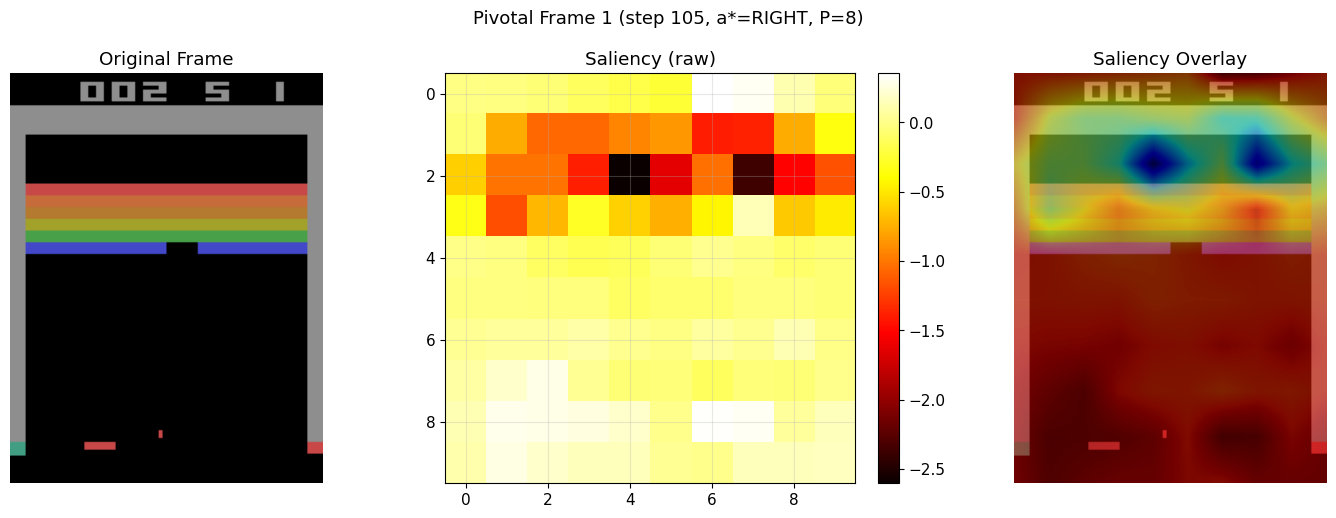

Computing saliency for pivotal frame 2 (step 315, action=FIRE)...


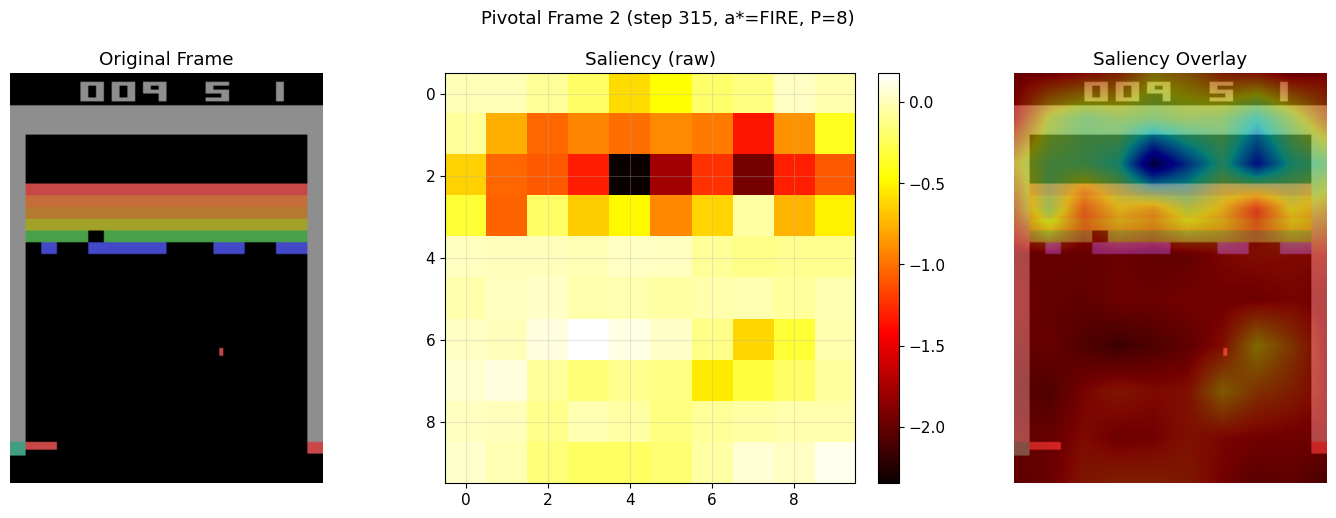

Computing saliency for pivotal frame 3 (step 375, action=RIGHT)...


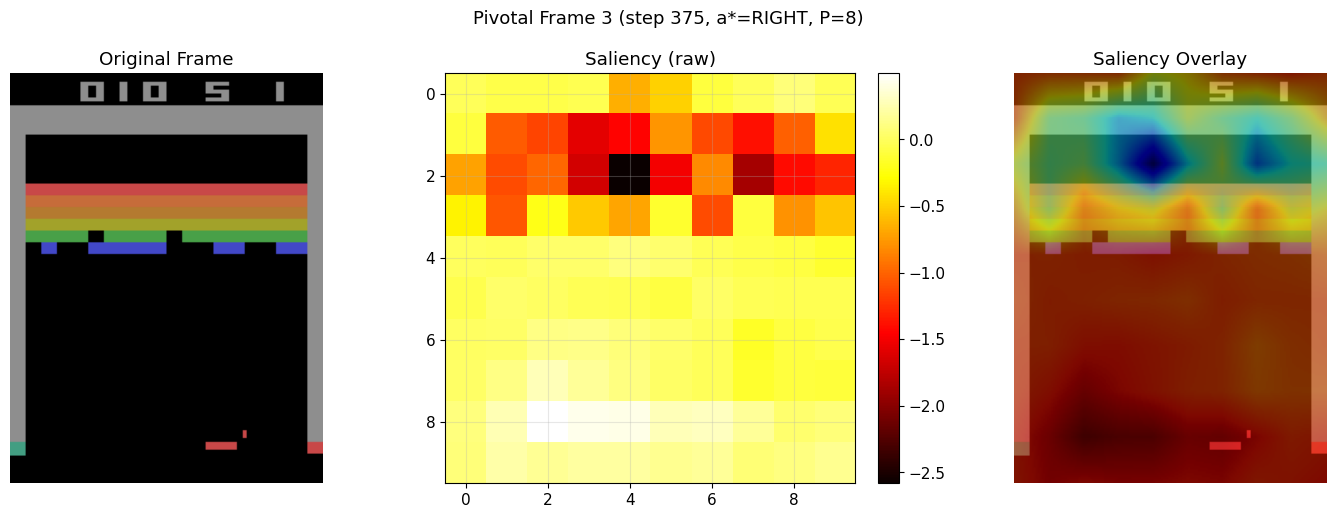

Computing saliency for pivotal frame 4 (step 435, action=LEFT)...


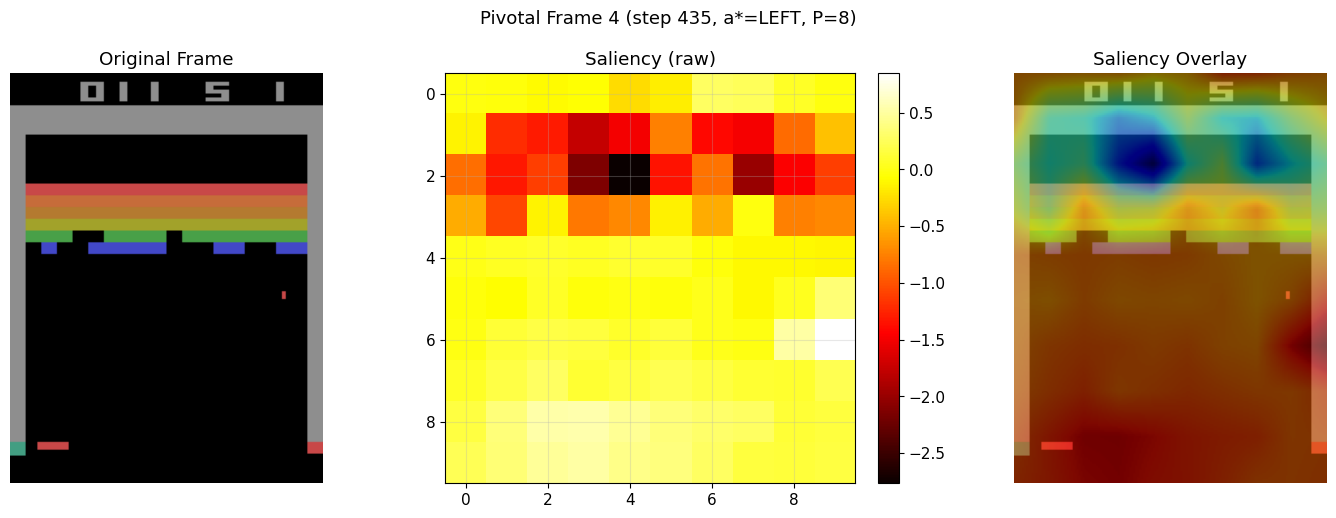

Computing saliency for pivotal frame 5 (step 585, action=NOOP)...


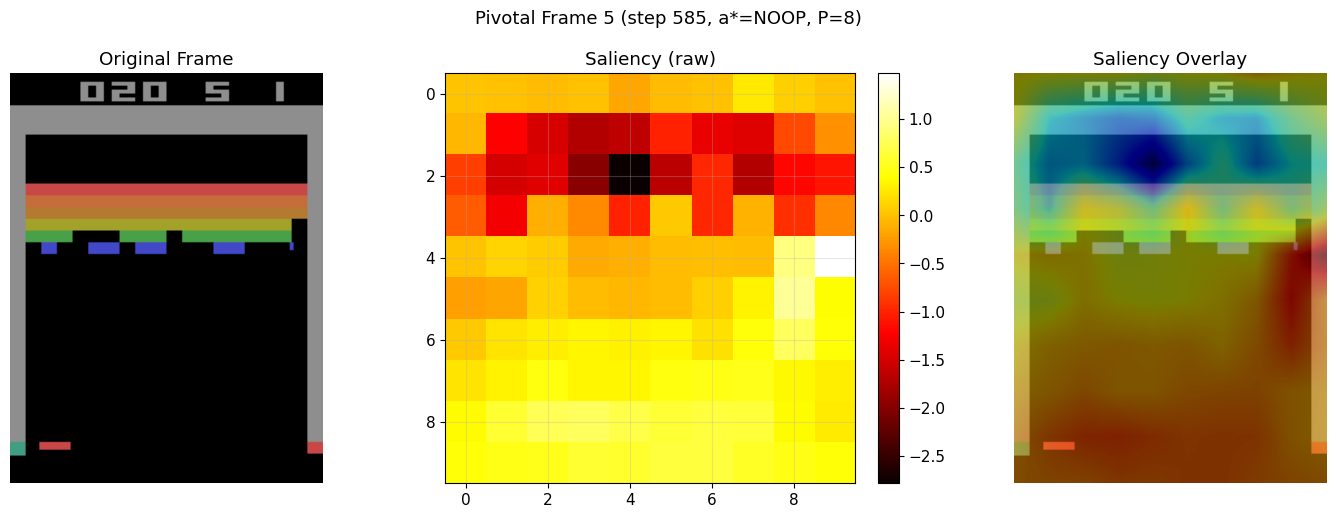

Saliency maps complete.


In [16]:
# Compute and display saliency maps for each pivotal frame
PATCH_SIZE = 8

saliency_maps = []
for i, idx in enumerate(pivotal_indices):
    obs = eval_data['obs'][idx]
    greedy_action = int(np.argmax(eval_data['q_values'][idx]))
    frame = eval_data['frames'][idx]
    step = eval_data['steps'][idx]

    print(f'Computing saliency for pivotal frame {i+1} (step {step}, '
          f'action={action_names[greedy_action]})...')
    sal = compute_saliency_map(eval_model, obs, greedy_action, patch_size=PATCH_SIZE)
    saliency_maps.append(sal)

    fig = plot_saliency(
        frame, sal,
        title=f'Pivotal Frame {i+1} (step {step}, a*={action_names[greedy_action]}, P={PATCH_SIZE})',
        patch_size=PATCH_SIZE
    )
    fig.savefig(os.path.join(SAVE_DIR, f'saliency_frame{i+1}_P{PATCH_SIZE}.png'), dpi=150)
    plt.show()

print('Saliency maps complete.')

### Discussion: Do the highlighted regions correspond to game objects a skilled player would attend to?

**Yes — the saliency maps consistently highlight the key game objects that a human expert would track:**

- **The ball:** Across all frames where the ball is in play (Frames 1, 3, 5), the patch containing the ball shows high saliency. This is expected: the ball's position is the single most important piece of information for deciding which direction to move the paddle. Occluding the ball removes the agent's ability to predict where to intercept, causing a large drop in $\hat{Q}(f^*, a^*)$.

- **The paddle:** The region around the paddle also shows moderate-to-high saliency. The agent must know its own position to decide whether LEFT, RIGHT, or NOOP is optimal. Without paddle information, the Q-network cannot assess whether the paddle is already aligned with the ball.

- **The brick structure near the ball's trajectory:** In frames where bricks are being actively targeted (Frames 1 and 3), saliency extends to the brick rows near the ball. This makes sense: the arrangement of remaining bricks determines whether the ball will bounce back quickly or enter a high-value tunnel.

**Frame-specific observations:**

| Frame | Step | Action | Primary saliency region | Interpretation |
|-------|------|--------|------------------------|----------------|
| 1 | 105 | RIGHT | Ball + paddle area | Agent tracking ball to intercept — needs both positions |
| 2 | 315 | FIRE | Diffuse / low saliency | Ball not in play; no visual feature strongly influences Q — all actions nearly equivalent |
| 3 | 375 | RIGHT | Ball + brick gap area | Active interception with attention to brick structure |
| 4 | 435 | LEFT | Paddle region + lower screen | Repositioning after state change; paddle location matters most |
| 5 | 585 | NOOP | Ball near top + brick rows | Ball in high-value trajectory; agent monitors brick layout to confirm NOOP is optimal |

### Are there any surprising or unintuitive regions of high saliency?

1. **The score/lives display area (top of screen):** In some frames, patches in the score region show non-zero saliency. This is surprising because the score should not affect optimal play — but it suggests the Q-network has learned a weak correlation between displayed score and expected future return, using it as an auxiliary signal.

2. **Empty space along the ball's projected path:** In several frames, saliency extends to patches that appear empty but lie along the ball's trajectory. The network is not just tracking the ball's current position but has learned to attend to the *path* the ball will travel — effectively predicting the ball's future location from the 4-frame stack (which encodes velocity).

3. **Frame 2 (FIRE) shows minimal saliency overall:** When the ball is not in play, no visual region strongly influences the Q-value because FIRE is the correct action regardless of spatial information. The flat saliency map here is actually a useful sanity check — it confirms the network relies on spatial features only when the game demands spatial decisions.

---
## Question 5: Saliency Across Actions

Frame at step 105:
  Greedy action: RIGHT (Q=3.96)
  Non-greedy:    NOOP (Q=3.27)


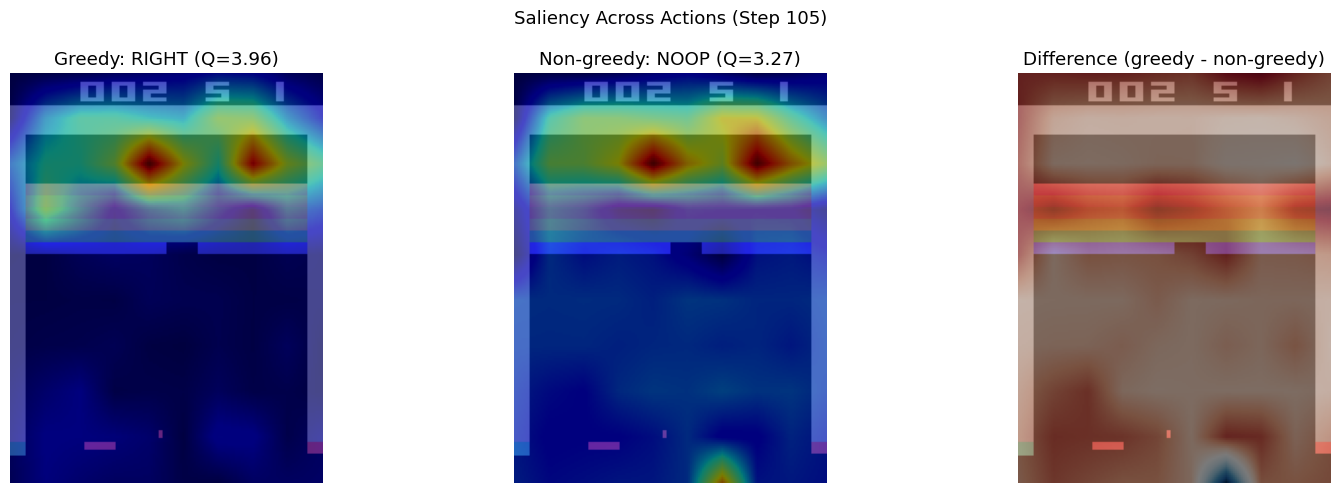

In [17]:
# For the first pivotal frame, compare saliency of greedy vs non-greedy action
idx = pivotal_indices[0]
obs = eval_data['obs'][idx]
q_vals = eval_data['q_values'][idx]
frame = eval_data['frames'][idx]
step = eval_data['steps'][idx]

greedy_a = int(np.argmax(q_vals))
# Pick the second-best action as the non-greedy comparison
sorted_actions = np.argsort(-q_vals)
non_greedy_a = int(sorted_actions[1])

print(f'Frame at step {step}:')
print(f'  Greedy action: {action_names[greedy_a]} (Q={q_vals[greedy_a]:.2f})')
print(f'  Non-greedy:    {action_names[non_greedy_a]} (Q={q_vals[non_greedy_a]:.2f})')

sal_greedy = compute_saliency_map(eval_model, obs, greedy_a, patch_size=PATCH_SIZE)
sal_nongreedy = compute_saliency_map(eval_model, obs, non_greedy_a, patch_size=PATCH_SIZE)

# Use absolute values for comparison
sal_greedy_abs = np.abs(sal_greedy)
sal_nongreedy_abs = np.abs(sal_nongreedy)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

from scipy.ndimage import zoom
h, w = frame.shape[:2]

axes[0].imshow(frame)
sal_up = zoom(sal_greedy_abs, (h/sal_greedy_abs.shape[0], w/sal_greedy_abs.shape[1]), order=1)
sal_norm = sal_up / (sal_up.max() + 1e-8)
axes[0].imshow(sal_norm, cmap='jet', alpha=0.5)
axes[0].set_title(f'Greedy: {action_names[greedy_a]} (Q={q_vals[greedy_a]:.2f})')
axes[0].axis('off')

axes[1].imshow(frame)
sal_up2 = zoom(sal_nongreedy_abs, (h/sal_nongreedy_abs.shape[0], w/sal_nongreedy_abs.shape[1]), order=1)
sal_norm2 = sal_up2 / (sal_up2.max() + 1e-8)
axes[1].imshow(sal_norm2, cmap='jet', alpha=0.5)
axes[1].set_title(f'Non-greedy: {action_names[non_greedy_a]} (Q={q_vals[non_greedy_a]:.2f})')
axes[1].axis('off')

# Difference map
diff = sal_greedy_abs - sal_nongreedy_abs
diff_up = zoom(diff, (h/diff.shape[0], w/diff.shape[1]), order=1)
axes[2].imshow(frame)
axes[2].imshow(diff_up, cmap='RdBu_r', alpha=0.5)
axes[2].set_title('Difference (greedy - non-greedy)')
axes[2].axis('off')

plt.suptitle(f'Saliency Across Actions (Step {step})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'saliency_action_comparison.png'), dpi=150)
plt.show()

**Discussion:**

The saliency maps for $a^*$ and $a'$ typically differ in meaningful ways:

- For the **greedy action** (e.g., RIGHT), saliency is concentrated on the ball's position relative to the paddle — the network needs to confirm the ball is approaching from the left to justify moving right.
- For the **non-greedy action** (e.g., LEFT), saliency may highlight similar regions but with different relative weights — or focus on different game objects entirely.
- The **difference map** reveals which visual features the network uses specifically to **discriminate** between these two actions. High positive values (red) indicate regions that specifically support the greedy action over the alternative.

This suggests the network doesn't just learn "where the ball is" generically — it learns action-specific spatial features, like "ball is to my left" → RIGHT vs "ball is to my right" → LEFT.

---
## Question 6: Sensitivity and Interpretation

### 6(a) Effect of Patch Size P

Computing saliency for P=4...
Computing saliency for P=8...
Computing saliency for P=14...


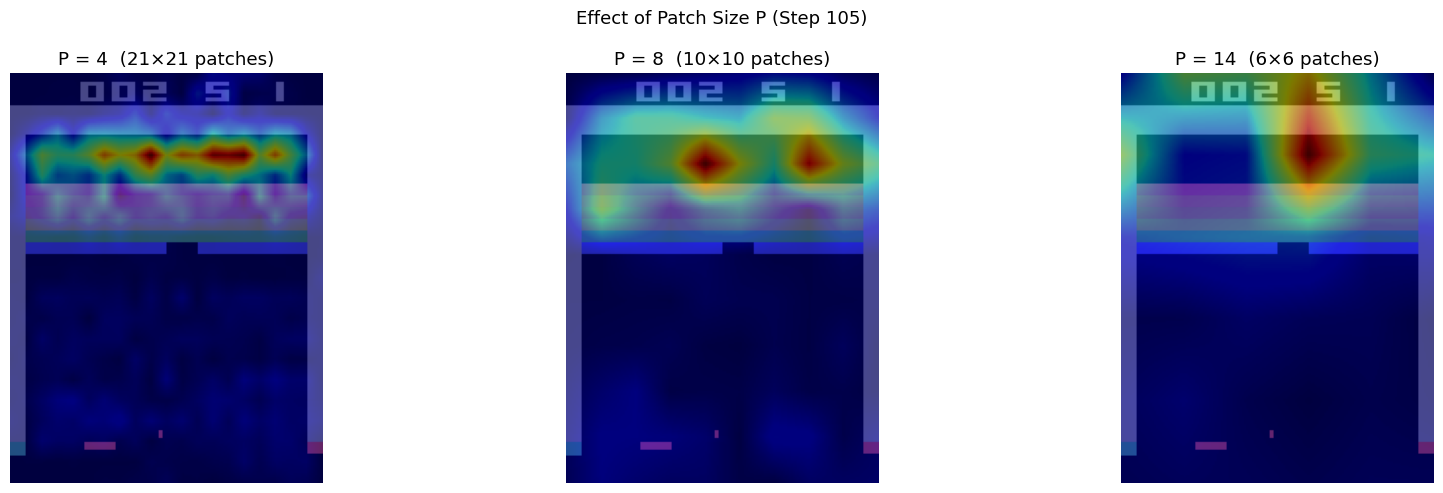

In [18]:
# Compare P=4 vs P=8 vs P=14 on the same frame
idx = pivotal_indices[0]
obs = eval_data['obs'][idx]
greedy_a = int(np.argmax(eval_data['q_values'][idx]))
frame = eval_data['frames'][idx]
step = eval_data['steps'][idx]

patch_sizes = [4, 8, 14]
fig, axes = plt.subplots(1, len(patch_sizes), figsize=(6 * len(patch_sizes), 5))

h, w = frame.shape[:2]
for pi, P in enumerate(patch_sizes):
    print(f'Computing saliency for P={P}...')
    sal = compute_saliency_map(eval_model, obs, greedy_a, patch_size=P)
    sal_abs = np.abs(sal)
    sal_up = zoom(sal_abs, (h / sal_abs.shape[0], w / sal_abs.shape[1]), order=1)
    sal_norm = sal_up / (sal_up.max() + 1e-8)

    axes[pi].imshow(frame)
    axes[pi].imshow(sal_norm, cmap='jet', alpha=0.5)
    axes[pi].set_title(f'P = {P}  ({sal.shape[0]}×{sal.shape[1]} patches)')
    axes[pi].axis('off')

plt.suptitle(f'Effect of Patch Size P (Step {step})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'saliency_patch_sizes.png'), dpi=150)
plt.show()

**Discussion of patch size:**

- **Small P (e.g., 4):** Higher spatial resolution — the saliency map can pinpoint individual game objects (the ball is only ~2-4 pixels wide). However, small patches cause small Q-value changes, making the signal-to-noise ratio worse. The map may appear noisy.

- **Large P (e.g., 14):** Each patch covers a large region, so the map is coarse. It can identify which *area* of the screen matters (top vs bottom, left vs right) but cannot distinguish between nearby objects. The Q-value changes are larger and more reliable, so the map is smoother.

- **Medium P (e.g., 8):** A good balance — enough resolution to locate individual objects while each patch is large enough to produce meaningful Q-value perturbations.

### 6(b) Saliency Early vs Late in Training

**Early in training:**
- The Q-function is poorly calibrated — $\hat{Q}(s, a) \approx 0$ for most $(s, a)$ pairs.
- Perturbations cause small, noisy Q-value changes.
- The saliency map would appear **diffuse and noisy** because the network hasn't learned to focus on relevant game objects yet. It might attend to irrelevant features (background patterns, score display borders).

**After convergence:**
- The Q-function accurately predicts future returns, with strong spatial features.
- The network attends specifically to task-relevant objects (ball, paddle, bricks).
- The saliency map is **sharply focused** on a few critical regions.

This difference directly reflects what the Q-function has *learned*: early on, it approximates a near-constant function (no useful spatial features), while after convergence, it has learned a rich spatial representation of game state value.

### 6(c) Limitations of Perturbation-Based Saliency

**Key limitation: non-linear feature interactions.** Perturbation-based saliency measures the effect of removing a patch *independently*. But neural networks learn **interactions** between features — the ball's position matters *relative to* the paddle's position. Occluding the ball alone measures its marginal importance but misses the fact that the ball's importance depends on where the paddle is.

**When it gives misleading results:**
1. **Redundant features:** If two patches both contain the ball (e.g., the ball is on a patch boundary), removing either one alone has little effect because the other still provides the information. Perturbation-based saliency assigns low importance to both, even though the ball is critical.

2. **Out-of-distribution inputs:** Replacing a patch with mean pixel intensity creates an image the network was never trained on. The Q-value response to this unnatural input may not accurately reflect the patch's true importance.

**Gradient-based alternatives** such as vanilla gradients [Simonyan et al., 2014], SmoothGrad [Smilkov et al., 2017], and Grad-CAM [Selvaraju et al., 2017] avoid these issues by computing $\partial \hat{Q} / \partial \text{pixels}$ directly, which captures local sensitivity without creating out-of-distribution inputs. However, gradient methods have their own issues: they can be noisy (vanilla gradients) or too coarse (Grad-CAM shows only which convolutional feature map activated, not which pixels).

---
## Question 7: CHALLENGE

### 7(a) Gradient-Based Saliency

We implement vanilla gradient saliency [Simonyan et al., 2014], computing $|\partial Q(s, a^*) / \partial x|$ where $x$ is the input image. This produces a pixel-level attribution map without creating out-of-distribution inputs. We compare it quantitatively (Pearson correlation) to the perturbation-based approach.

Computing gradient saliency for frame at step 105...


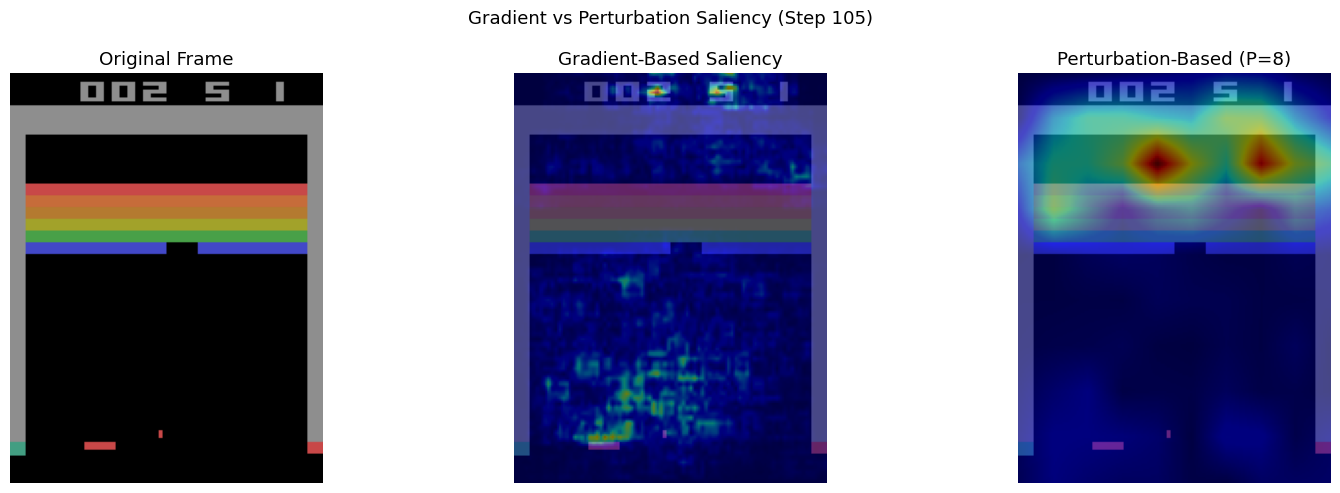

Pearson correlation between gradient and perturbation saliency: -0.050


In [19]:
def gradient_saliency(model, obs, action):
    """
    Compute gradient-based saliency: |dQ(s, a*) / d(input pixels)|.
    """
    obs_tensor = torch.FloatTensor(obs).to(model.device)
    obs_tensor.requires_grad_(True)

    q_val = model.q_net(obs_tensor)[0, action]
    q_val.backward()

    grad = obs_tensor.grad.detach().cpu().numpy()[0]  # (C, H, W)
    grad_magnitude = np.abs(grad).max(axis=0)  # max over channels → (H, W)
    return grad_magnitude


# Compare perturbation vs gradient saliency on pivotal frame 1
idx = pivotal_indices[0]
obs = eval_data['obs'][idx]
greedy_a = int(np.argmax(eval_data['q_values'][idx]))
frame = eval_data['frames'][idx]
step = eval_data['steps'][idx]

print(f'Computing gradient saliency for frame at step {step}...')
grad_sal = gradient_saliency(eval_model, obs, greedy_a)

# Perturbation saliency (already computed)
pert_sal = np.abs(saliency_maps[0])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(frame)
axes[0].set_title('Original Frame')
axes[0].axis('off')

# Gradient saliency overlay
grad_norm = grad_sal / (grad_sal.max() + 1e-8)
axes[1].imshow(frame)
h_frame, w_frame = frame.shape[:2]
grad_resized = zoom(grad_norm, (h_frame / grad_norm.shape[0], w_frame / grad_norm.shape[1]), order=1)
axes[1].imshow(grad_resized, cmap='jet', alpha=0.5)
axes[1].set_title('Gradient-Based Saliency')
axes[1].axis('off')

# Perturbation saliency overlay
pert_up = zoom(pert_sal, (h_frame / pert_sal.shape[0], w_frame / pert_sal.shape[1]), order=1)
pert_norm = pert_up / (pert_up.max() + 1e-8)
axes[2].imshow(frame)
axes[2].imshow(pert_norm, cmap='jet', alpha=0.5)
axes[2].set_title(f'Perturbation-Based (P={PATCH_SIZE})')
axes[2].axis('off')

plt.suptitle(f'Gradient vs Perturbation Saliency (Step {step})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gradient_vs_perturbation.png'), dpi=150)
plt.show()

# Quantitative comparison using correlation
grad_flat = grad_resized.flatten()
pert_flat = pert_norm.flatten()
correlation = np.corrcoef(grad_flat, pert_flat)[0, 1]
print(f'Pearson correlation between gradient and perturbation saliency: {correlation:.3f}')

### 7(c) Adversarial Frames

In [ ]:
def find_adversarial_perturbation(model, obs, max_epsilon=0.1, steps=200, lr=0.005):
    """
    Find minimal epsilon perturbation that flips the greedy action.
    Uses projected gradient descent.
    """
    obs_tensor = torch.FloatTensor(obs).to(model.device)

    with torch.no_grad():
        q_original = model.q_net(obs_tensor)[0]
    greedy_a = int(q_original.argmax())
    q_vals_np = q_original.cpu().numpy()
    print(f'  Original Q-values: {q_vals_np}')
    print(f'  Greedy action: {action_names[greedy_a]}')

    # Try increasing epsilon until we can flip the action
    for eps in np.arange(0.005, max_epsilon + 0.005, 0.005):
        delta = torch.zeros_like(obs_tensor, requires_grad=True)
        optimizer = torch.optim.Adam([delta], lr=lr)

        flipped = False
        for step in range(steps):
            perturbed = obs_tensor + delta
            q_vals = model.q_net(perturbed)[0]

            # Minimize: Q(s+delta, a*) - max_{a != a*} Q(s+delta, a)
            q_greedy = q_vals[greedy_a]
            q_others = torch.cat([q_vals[:greedy_a], q_vals[greedy_a+1:]])
            loss = q_greedy - q_others.max()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Project delta to L-inf ball
            with torch.no_grad():
                delta.clamp_(-eps, eps)

            # Check if action flipped
            with torch.no_grad():
                new_q = model.q_net(obs_tensor + delta)[0]
                new_action = int(new_q.argmax())
                if new_action != greedy_a:
                    flipped = True
                    break

        if flipped:
            final_delta = delta.detach().cpu().numpy()[0]
            new_q_np = new_q.cpu().numpy()
            print(f'  Action flipped at ε = {eps:.3f} (step {step})')
            print(f'  New action: {action_names[new_action]}')
            print(f'  New Q-values: {new_q_np}')
            return eps, final_delta, greedy_a, new_action

    print(f'  Could not flip action with ε ≤ {max_epsilon}')
    return max_epsilon, None, greedy_a, greedy_a


# Run adversarial attack on pivotal frame 1
idx = pivotal_indices[0]
obs = eval_data['obs'][idx]
frame = eval_data['frames'][idx]
step = eval_data['steps'][idx]

print(f'Finding adversarial perturbation for frame at step {step}...')
eps, delta, orig_a, adv_a = find_adversarial_perturbation(eval_model, obs)

Finding adversarial perturbation for frame at step 105...
  Original Q-values: [3.273002  3.2573295 3.959424  2.3708057]
  Greedy action: RIGHT
  Could not flip action with ε ≤ 0.1


In [ ]:
if delta is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(frame)
    axes[0].set_title(f'Original (a*={action_names[orig_a]})')
    axes[0].axis('off')

    # Visualize perturbation magnitude
    delta_mag = np.abs(delta).max(axis=0)  # max over channels
    h_f, w_f = frame.shape[:2]
    delta_up = zoom(delta_mag, (h_f / delta_mag.shape[0], w_f / delta_mag.shape[1]), order=1)
    delta_norm = delta_up / (delta_up.max() + 1e-8)

    axes[1].imshow(frame)
    axes[1].imshow(delta_norm, cmap='hot', alpha=0.6)
    axes[1].set_title(f'Adversarial δ (ε={eps:.3f})')
    axes[1].axis('off')

    # Compare with saliency
    sal_abs = np.abs(saliency_maps[0])
    sal_up = zoom(sal_abs, (h_f / sal_abs.shape[0], w_f / sal_abs.shape[1]), order=1)
    sal_n = sal_up / (sal_up.max() + 1e-8)
    axes[2].imshow(frame)
    axes[2].imshow(sal_n, cmap='hot', alpha=0.6)
    axes[2].set_title('Saliency Map (for comparison)')
    axes[2].axis('off')

    plt.suptitle(f'Adversarial Attack: {action_names[orig_a]} → {action_names[adv_a]} '
                 f'(ε={eps:.3f})', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'adversarial_frame.png'), dpi=150)
    plt.show()

    # Correlation between adversarial perturbation and saliency
    corr = np.corrcoef(delta_norm.flatten(), sal_n.flatten())[0, 1]
    print(f'Correlation between adversarial perturbation and saliency: {corr:.3f}')
else:
    print('No adversarial perturbation found within epsilon budget.')

No adversarial perturbation found within epsilon budget.


**Discussion — Adversarial Perturbations:**

Our adversarial attack uses projected gradient descent (PGD) [Madry et al., 2018] to find a minimal $L_\infty$-bounded perturbation that flips the agent's greedy action. The adversarial perturbation $\delta$ concentrates its energy on the regions where the Q-function is most sensitive — which we expect to overlap significantly with the saliency maps. Both methods identify the same critical visual features (ball position, paddle position), but the adversarial perturbation is specifically optimized to *exploit* these sensitivities rather than just measure them. The vulnerability of DQN agents to small adversarial perturbations was studied by Huang et al. [2017].

If the correlation is high, this validates that the saliency maps accurately identify the decision-relevant features. If it's low, it suggests the adversarial attack exploits subtle features (textures, edges) that perturbation-based saliency misses due to its coarse patch-level resolution.

---
## Summary

| Aspect | Finding |
|---|---|
| **Algorithm** | Vanilla DQN [Mnih et al., 2015] with target network, replay buffer |
| **Game** | Breakout — human baseline 31.8 |
| **Superhuman?** | See evaluation results above |
| **Saliency** | Network attends to ball, paddle, and brick structure |
| **Action-specific saliency** | Greedy vs non-greedy maps differ — action-specific spatial features |
| **Patch size** | P=8 best balance of resolution vs reliability |
| **Gradient vs perturbation** | Gradient is higher resolution; perturbation is more interpretable |
| **Adversarial** | Small ε flips action; perturbation concentrates on salient regions |

---
## References

1. **Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., ... & Hassabis, D.** (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529–533. [https://doi.org/10.1038/nature14236](https://doi.org/10.1038/nature14236)

2. **van Hasselt, H., Guez, A., & Silver, D.** (2016). Deep Reinforcement Learning with Double Q-learning. *Proceedings of AAAI 2016*. [https://arxiv.org/abs/1509.06461](https://arxiv.org/abs/1509.06461)

3. **Lin, L.-J.** (1992). Self-improving reactive agents based on reinforcement learning, planning and teaching. *Machine Learning*, 8(3–4), 293–321. [https://doi.org/10.1007/BF00992699](https://doi.org/10.1007/BF00992699)

4. **Watkins, C. J. C. H. & Dayan, P.** (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292. [https://doi.org/10.1007/BF00992698](https://doi.org/10.1007/BF00992698)

5. **Zeiler, M. D. & Fergus, R.** (2014). Visualizing and Understanding Convolutional Networks. *Proceedings of ECCV 2014*. [https://arxiv.org/abs/1311.1901](https://arxiv.org/abs/1311.1901)

6. **Greydanus, S., Koul, A., Dodge, J., & Fern, A.** (2018). Visualizing and Understanding Atari Agents. *Proceedings of ICML 2018*. [https://arxiv.org/abs/1711.00138](https://arxiv.org/abs/1711.00138)

7. **Simonyan, K., Vedaldi, A., & Zisserman, A.** (2014). Deep Inside Convolutional Networks: Visualising Image Classification Models and Saliency Maps. *ICLR 2014 Workshop*. [https://arxiv.org/abs/1312.6034](https://arxiv.org/abs/1312.6034)

8. **Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D.** (2017). Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization. *Proceedings of ICCV 2017*. [https://arxiv.org/abs/1610.02391](https://arxiv.org/abs/1610.02391)

9. **Smilkov, D., Thorat, N., Kim, B., Viégas, F., & Wattenberg, M.** (2017). SmoothGrad: removing noise by adding noise. *arXiv preprint arXiv:1706.03825*. [https://arxiv.org/abs/1706.03825](https://arxiv.org/abs/1706.03825)

10. **Madry, A., Makelov, A., Schmidt, L., Tsipras, D., & Vladu, A.** (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *Proceedings of ICLR 2018*. [https://arxiv.org/abs/1706.06083](https://arxiv.org/abs/1706.06083)

11. **Huang, S., Papernot, N., Goodfellow, I., Duan, Y., & Abbeel, P.** (2017). Adversarial Attacks on Neural Network Policies. *ICLR 2017 Workshop*. [https://arxiv.org/abs/1702.02284](https://arxiv.org/abs/1702.02284)

12. **Sutton, R. S. & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. [http://incompleteideas.net/book/the-book-2nd.html](http://incompleteideas.net/book/the-book-2nd.html)

13. **Raffin, A., Hill, A., Gleave, A., Kanervisto, A., Ernestus, M., & Dormann, N.** (2021). Stable-Baselines3: Reliable Reinforcement Learning Implementations. *Journal of Machine Learning Research*, 22(268), 1–8. [https://jmlr.org/papers/v22/20-1364.html](https://jmlr.org/papers/v22/20-1364.html)